<a href="https://colab.research.google.com/github/rani-sikdar/Credit-Card-Fraud-Detection/blob/main/credit_card_fraud_detection_RandomForest_%26_Logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
path="/content/creditcard.csv"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec


In [6]:
df = pd.read_csv(path)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [14]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [19]:
# Analyze and check distribution of fraudlent vs normal transactions
# seperate datset into two groups - 0 1
fraud= df[df['Class']==1]
valid= df[df['Class']==0]

outlierFraction = len(fraud)/len(valid)

print(round(outlierFraction,5))
print("Fraud cases: ", len(fraud))
print("Valid cases: ", len(valid))

0.00173
Fraud cases:  492
Valid cases:  284315


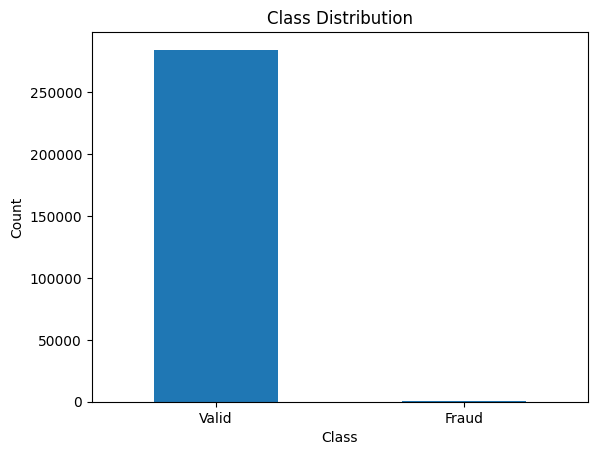

In [49]:
#visualize the data:

labels = ["Valid", "Fraud"]
count_classes = df.value_counts(df['Class'], sort= True)
count_classes.plot(kind = "bar", rot = 0)
plt.title("Class Distribution")
plt.ylabel("Count")
plt.xticks(range(2), labels)
plt.show()

In [21]:
print("Amount details of the fraudulent transaction")
fraud.Amount.describe()

Amount details of the fraudulent transaction


,Amount
count,492.000000
mean,122.211321
std,256.683288
min,0.000000
25%,1.000000
50%,9.250000
75%,105.890000
max,2125.870000


In [22]:
print("Amount details of the valid transaction")
valid.Amount.describe()

Amount details of the valid transaction


,Amount
count,284315.000000
mean,88.291022
std,250.105092
min,0.000000
25%,5.650000
50%,22.000000
75%,77.050000
max,25691.160000


In [23]:
# from the above details, we can observe that fraud transactions have higher average

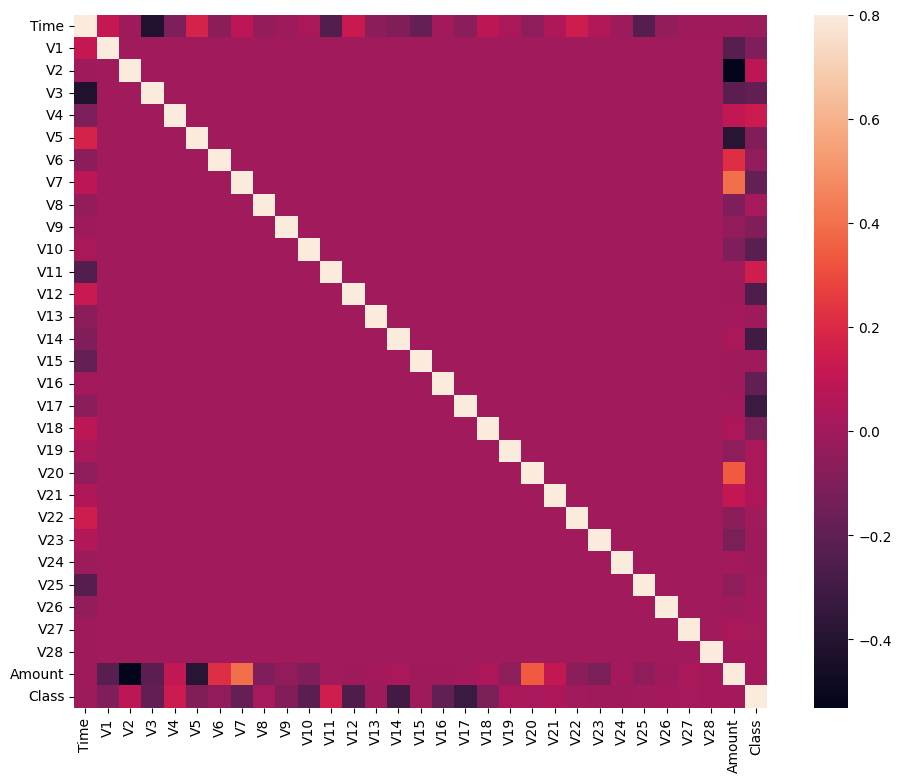

In [28]:
# plotting correlation matrix
matrix = df.corr()
# matrix

fig= plt.figure(figsize=(12,9))
sns.heatmap(matrix, vmax=.8, square=True)
plt.show()

In [33]:
# preparing data
# sepearte x and y

X = df.drop(['Class'], axis=1)
Y= df['Class']

print(X.shape, Y.shape)

xData = X.values
yData = Y.values

# model

from sklearn.model_selection import train_test_split
xTrain, xTest, yTrain, yTest = train_test_split(
    xData, yData, test_size=0.2, random_state=50)

(284807, 30) (284807,)


In [35]:
print(xTrain.shape, yTrain.shape)
print(xTest.shape, yTest.shape)

(227845, 30) (227845,)
(56962, 30) (56962,)


In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [46]:
# Build & Train a model- Logistic Regression

lr = LogisticRegression(penalty='l1', solver='liblinear') # Added solver for l1 penalty
lr.fit(xTrain, yTrain)

yPreds = lr.predict(xTest)

Model Evluation Metrics: 
Accuracy: 0.9992
Precision: 0.8060
Recall: 0.6136
F1 score: 0.6968
Matthew Corr Coef: 0.7029


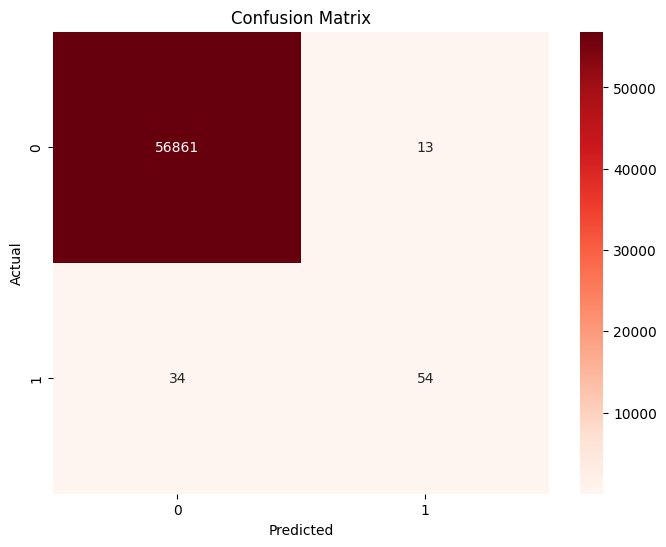

In [47]:
# evaluate model - Logistic Regression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
from sklearn.metrics import classification_report

accuracy = accuracy_score(yTest, yPreds)
precision = precision_score(yTest, yPreds)
recall = recall_score(yTest, yPreds)
f1 = f1_score(yTest, yPreds)
mcc = matthews_corrcoef(yTest, yPreds)

print("Model Evluation Metrics: ")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 score: {f1:.4f}")
print(f"Matthew Corr Coef: {mcc:.4f}")

confusion_matrix = confusion_matrix(yTest, yPreds)
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Reds")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [53]:
# classification report
print(classification_report(yTest, yPreds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56874
           1       0.81      0.61      0.70        88

    accuracy                           1.00     56962
   macro avg       0.90      0.81      0.85     56962
weighted avg       1.00      1.00      1.00     56962



In [39]:
# Build & Train a model- Random Forest Classifier

rfc= RandomForestClassifier(n_estimators=100, criterion='gini', random_state=50, verbose= 1)
rfc.fit(xTrain, yTrain)

yPred= rfc.predict(xTest)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  3.8min
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:  7.8min finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.6s finished


Model Evluation Metrics: 
Accuracy: 0.9996
Precision: 0.9571
Recall: 0.7614
F1 score: 0.8481
Matthew Corr Coef: 0.8535


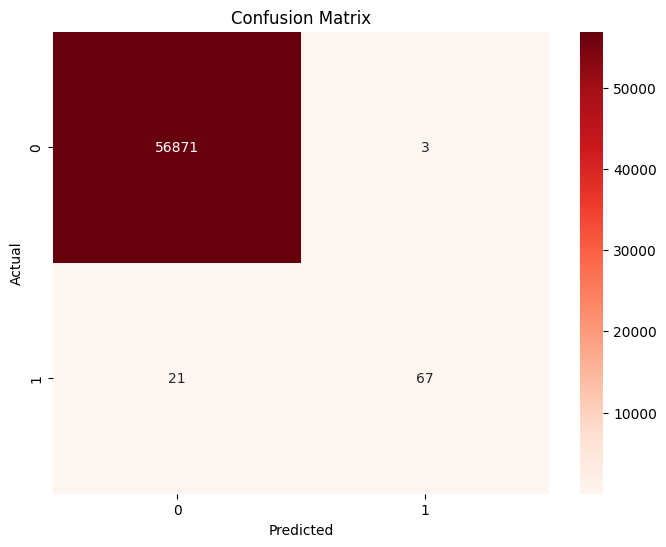

In [43]:
# evaluate model - Random Forest Classifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix
from sklearn.metrics import classification_report

accuracy = accuracy_score(yTest, yPred)
precision = precision_score(yTest, yPred)
recall = recall_score(yTest, yPred)
f1 = f1_score(yTest, yPred)
mcc = matthews_corrcoef(yTest, yPred)

print("Model Evluation Metrics: ")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 score: {f1:.4f}")
print(f"Matthew Corr Coef: {mcc:.4f}")

confusion_matrix = confusion_matrix(yTest, yPred)
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Reds")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [54]:
# classification report
print(classification_report(yTest, yPred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56874
           1       0.96      0.76      0.85        88

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962

